# Regime Model

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.regime_model import *
import pandas as pd

df = pd.read_parquet("../data/processed/regime_features_scaled.parquet")

features = [
"spx_vol_20",
"spx_vol_60",
"vol_ratio",
"vol_gradient",
"vix_level",
"stress_index",
"amihud_illiquidity",
"volume_spike",
"spx_sq_return",
"us10y_vol"
]

X = df[features].values

In [3]:
model, k, bic = select_hmm_model(X)

print("Best regime count:", k)

Model is not converging.  Current: -4540.645294993692 is not greater than -4540.641610379004. Delta is -0.00368461468769965
Model is not converging.  Current: 1418.4560354696198 is not greater than 1418.4719321196164. Delta is -0.015896649996648193


Best regime count: 4


In [4]:
df["regime_state"] = model.predict_states(X)

probs = model.predict_proba(X)

for i in range(probs.shape[1]):
    df[f"regime_prob_{i}"] = probs[:, i]

In [6]:
from src.regime_diagnostics import *

regime_summary(df, return_col="spx_sq_return")

,regime,count,mean_return,volatility,mean_vix,mean_stress
0,0,431,2.170490,2.624862,2.358923,2.360846
1,1,2974,0.154592,0.740837,0.410752,0.354012
2,2,3542,-0.360840,0.093632,-0.554469,-0.510845
3,3,288,-0.405265,0.037424,-0.953830,-0.907040


In [7]:
transition_matrix(df)

,0,1,2,3
0,0.761021,0.204176,0.011601,0.023202
1,0.027582,0.802556,0.166835,0.003027
2,0.005364,0.136364,0.845850,0.012422
3,0.006944,0.055556,0.156250,0.781250


In [8]:
df[["regime_prob_0","regime_prob_1","regime_prob_2","regime_prob_3"]].head()

,regime_prob_0,regime_prob_1,regime_prob_2,regime_prob_3
Date,,,,
2001-02-20,0.000000e+00,1.0,0.000000e+00,0.000000e+00
2001-02-21,7.749896e-08,1.0,6.207038e-75,0.000000e+00
2001-02-22,3.270387e-07,1.0,2.911393e-15,4.507858e-16
2001-02-23,2.404610e-07,1.0,5.090831e-30,8.376103e-26
2001-02-26,8.841777e-08,1.0,2.395217e-76,1.070849e-283


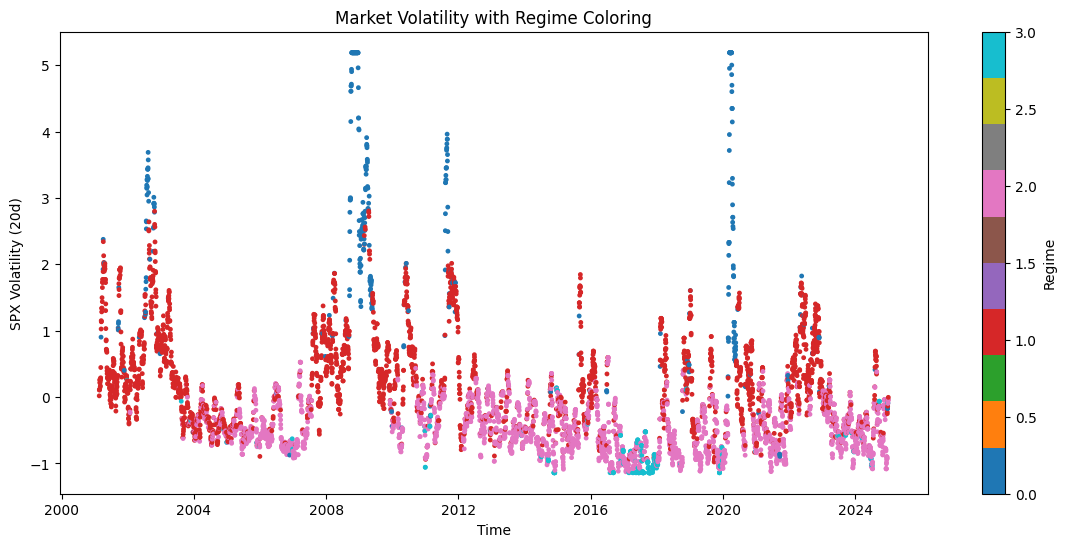

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

scatter = plt.scatter(
    df.index,
    df["spx_vol_20"],
    c=df["regime_state"],
    cmap="tab10",
    s=6
)

plt.colorbar(scatter, label="Regime")
plt.title("Market Volatility with Regime Coloring")
plt.xlabel("Time")
plt.ylabel("SPX Volatility (20d)")

plt.show()

In [10]:
# Order regimes by volatility level
vol_order = (
    df.groupby("regime_state")["spx_vol_20"]
    .mean()
    .sort_values()
    .index
)

# Create mapping old_regime → ordered_regime
mapping = {old: new for new, old in enumerate(vol_order)}

# Apply mapping
df["ordered_regime"] = df["regime_state"].map(mapping)

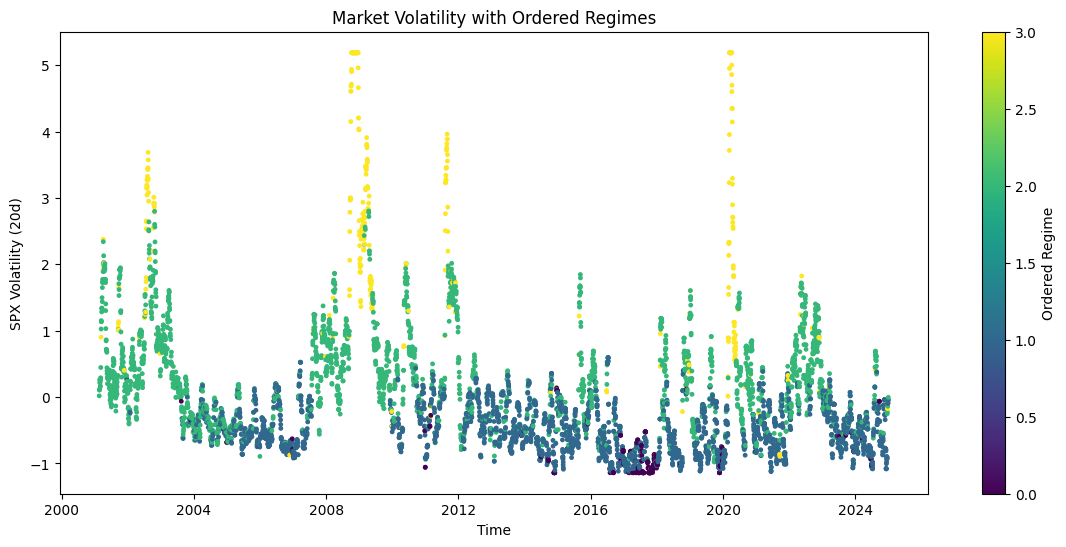

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

scatter = plt.scatter(
    df.index,
    df["spx_vol_20"],
    c=df["ordered_regime"],
    cmap="viridis",
    s=6
)

plt.colorbar(scatter, label="Ordered Regime")
plt.title("Market Volatility with Ordered Regimes")
plt.xlabel("Time")
plt.ylabel("SPX Volatility (20d)")

plt.show()

In [12]:
df.groupby("ordered_regime")[["spx_vol_20","vix_level","stress_index"]].mean()

,spx_vol_20,vix_level,stress_index
ordered_regime,,,
0,-0.881100,-0.953830,-0.907040
1,-0.521146,-0.554469,-0.510845
2,0.346003,0.410752,0.354012
3,2.484047,2.358923,2.360846


In [17]:
regime_summary(df, regime_col="ordered_regime", return_col="spx_sq_return")

,regime,count,mean_return,volatility,mean_vix,mean_stress
0,0,288,-0.405265,0.037424,-0.953830,-0.907040
1,1,3542,-0.360840,0.093632,-0.554469,-0.510845
2,2,2974,0.154592,0.740837,0.410752,0.354012
3,3,431,2.170490,2.624862,2.358923,2.360846


In [18]:
transition_matrix(df, regime_col="ordered_regime")

,0,1,2,3
0,0.781250,0.156250,0.055556,0.006944
1,0.012422,0.845850,0.136364,0.005364
2,0.003027,0.166835,0.802556,0.027582
3,0.023202,0.011601,0.204176,0.761021


In [19]:
df.to_parquet("../data/processed/regime_dataset.parquet")

# Rolling Model

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.regime_diagnostics import (
    regime_summary,
    transition_matrix,
    regime_durations,
    plot_regimes
)

df = pd.read_parquet("../data/processed/regime_dataset.parquet")

df = df.dropna()